# # Wine Quality Prediction 

In [2]:
# Workflow of Machine Learning Model
'''
0) Import Important dependencies
1) Setting up the data
2) Creating the Model
3) Training the Model
4) Testing the Model
5) Prediction
'''

'\n0) Import Important dependencies\n1) Setting up the data\n2) Creating the Model\n3) Training the Model\n4) Testing the Model\n5) Prediction\n'

## 1. Import libraries

In [3]:
# Import Important dependencies
import pandas as pd
import numpy as np

In [4]:
# Importing Train Test Split function
from sklearn.model_selection import train_test_split
# Importing accuracy score
from sklearn.metrics import accuracy_score
# Visual Analysis
import matplotlib.pyplot as plt
import seaborn as sns
# Model
from sklearn.ensemble import RandomForestClassifier

In [5]:
# Important features of random forest classifier
'''
1) Reduce Overfitting
2) Improved Accuracy
3) Handles missing data
'''

'\n1) Reduce Overfitting\n2) Improved Accuracy\n3) Handles missing data\n'

## 2. Load dataset

In [7]:
# Load the dataset
df = pd.read_csv('Winequality-red.csv')

In [8]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## 3. Data preprocessing

In [9]:
# Info the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [10]:
# Student - Exam
'''
He/she learnt entire text book line by line.
Training - Ask any question - Answer
Testing - Fail

Machine Fails here because it has understood too many things using the data.
But when new set of data is given for prediction it fails.

How it handles missing data
column1         column2
pepsi 500ml.    50
coke  500ml.    60
fanta 500ml.    60
sprite 500ml.   70
'''

'\nHe/she learnt entire text book line by line.\nTraining - Ask any question - Answer\nTesting - Fail\n\nMachine Fails here because it has understood too many things using the data.\nBut when new set of data is given for prediction it fails.\n\nHow it handles missing data\ncolumn1         column2\npepsi 500ml.    50\ncoke  500ml.    60\nfanta 500ml.    60\nsprite 500ml.   70\n'

In [11]:
# Check null values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [12]:
# Find unique value in quality
pd.unique(df['quality'])

array([5, 6, 7, 4, 8, 3])

In [13]:
# Display the count of different Wine quality
df['quality'].value_counts().reset_index()

,quality,count
0,5,681
1,6,638
2,7,199
3,4,53
4,8,18
5,3,10


## 4. Data visualization

Text(0.5, 1.0, 'Count the Quality ')

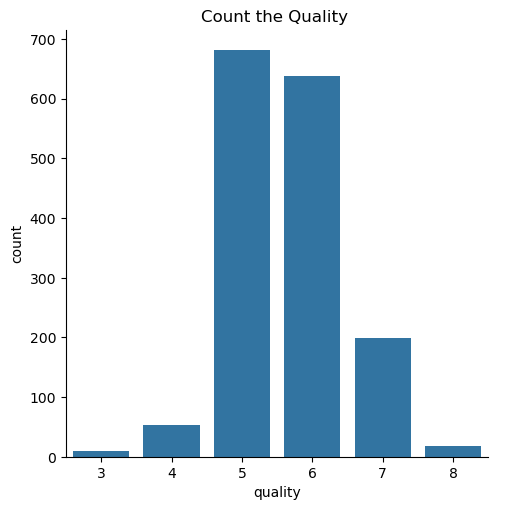

In [14]:
# Display Count of wine quality visually
sns.catplot(x = 'quality', data = df, kind = 'count')
plt.title("Count the Quality ")

In [15]:
# Find the highest alocohol concentration
print("Highest concentration of alochol is",df['alcohol'].max())

Highest concentration of alochol is 14.9


In [16]:
# Input Feature - X
# Target Column - Y
X = df.drop('quality', axis = 1)
Y = df['quality']

In [17]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [18]:
Y

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64

## 5. Train-test split

In [27]:
# Splitting the data into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [20]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(1599, 11)
(1279, 11)
(320, 11)


## 6. Train Random Forest model

In [28]:
# Model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

## 7. Evaluate model accuracy

In [29]:
# Accuracy score of training data
training_data_prediction = model.predict(X_train)
# Accuracy Score
training_data_accuracy = accuracy_score(Y_train, training_data_prediction)
print("Accuracy score of Training data is",training_data_accuracy)

Accuracy score of Training data is 1.0


In [30]:
# Accuracy score of testing data
testing_data_prediction = model.predict(X_test)
# Accuracy score
testing_data_accuracy = accuracy_score(Y_test, testing_data_prediction)
print("Accuracy score of Testing data is",testing_data_accuracy)

Accuracy score of Testing data is 0.659375


In [31]:
'''
# Overfitting
80% - Training data - Understood by the machine
20% - Unique values - Overfitted'''

'\n# Overfitting\n80% - Training data - Understood by the machine\n20% - Unique values - Overfitted'

In [32]:
# Building a predictive syetem
input_data = (7.9,0.32,0.51,1.8,0.341,17.0,56.0,0.9969,3.04,1.08,9.2)
input_data_array = np.asarray(input_data)
input_data_reshape = input_data_array.reshape(1,-1)

## 8. Predict wine quality

In [33]:
# Predition
prediction = model.predict(input_data_reshape)
print("The quality of the wine based on the given input is", prediction)

The quality of the wine based on the given input is [6]


C:\Users\Balamurugan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
